### Analyze and process Shovels data for North Carolina permitting fact sheet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [60]:
#Use last 10 years of data only
START_YEAR = 2016
END_YEAR = 2025

## Load data

In [61]:
DATA_DIRECTORY = Path("../data")
DATA_FILE_PATH = "permitpower-nc.csv"

all_permits = pd.read_csv(DATA_DIRECTORY / DATA_FILE_PATH, escapechar="\\")
print(f"Total number of permit records: {len(all_permits):,} records")

Total number of permit records: 4,202,005 records


## Only completed permits

We want to filter out any permits that aren't final yet, because they won't have valid ending dates. 

In [62]:
status = all_permits['STATUS'].fillna('').str.strip()
final_permits = all_permits[status.isin(['final', ''])].copy()

print(f"After status filter: {len(final_permits):,} records")

After status filter: 3,355,489 records


## Process date variables and filter by start year

In [63]:
date_cols = ['FILE_DATE', 'ISSUE_DATE', 'FINAL_DATE']
for col in date_cols:
    if col in final_permits.columns:
        final_permits[col] = pd.to_datetime(final_permits[col], errors='coerce')

final_permits['starting_date'] = final_permits[['FILE_DATE', 'ISSUE_DATE']].min(axis=1)
final_permits['ending_date'] = final_permits[['FINAL_DATE', 'ISSUE_DATE']].max(axis=1)
final_permits['Year'] = final_permits['starting_date'].dt.year
final_permits.loc[final_permits['ending_date'].dt.year > END_YEAR, 'ending_date'] = pd.NaT

dated_permits = final_permits[final_permits['Year'].between(START_YEAR, END_YEAR)].copy()

print(f"After year filter: {len(dated_permits):,} records")

After year filter: 2,291,327 records


## Calculate date variables and remove invalid project lengths

In [64]:
dated_permits['Project_Time'] = (dated_permits['ending_date'] - dated_permits['starting_date']).dt.days
dated_permits['Approval_Time'] = (dated_permits['ISSUE_DATE'] - dated_permits['FILE_DATE']).dt.days

valid_permits = dated_permits[
    (dated_permits['Approval_Time'] >= 0) &
    (dated_permits['Project_Time'] >= 0)
].copy()

print(f"After removing invalid durations: {len(valid_permits):,} records")

After removing invalid durations: 1,787,912 records


## Residential, non new-construction

* Remove new construction
* Filter to only residential properties (or blank, which we treat as residential)

In [ ]:
new_construction_filter = valid_permits[
    (valid_permits['NEW_CONSTRUCTION'] != 1) &
    ~valid_permits['SUBTYPE'].fillna('').str.contains('new construction', case=False) &
    ~valid_permits['TYPE'].fillna('').str.contains('new construction', case=False)
].copy()
print(f"After dropping new construction: {len(new_construction_filter):,} records")

residential_filter = new_construction_filter[
    new_construction_filter['PROPERTY_TYPE'].str.lower().isin(['residential']) |
    new_construction_filter['PROPERTY_TYPE'].isna() |
    (new_construction_filter['PROPERTY_TYPE'] == '')
].copy()
print(f"After filtering to residential: {len(residential_filter):,} records")

### Additional project type filtering to find non-residential 

Use regex pattern matching on PROPERTY_TYPE_DETAIL to flag projects that are tagged residential but actually include non-residential project type details. 

In [66]:
residential_pattern = (
    r'home|residence|triplex|townhouse|single family|condo|residential|'
    r'quadruplex|planned unit development|multi|module|mobile|house|duplex|'
    r'common|apartment|vacant land|timeshare|parcel with improvements|general|'
    r'dormitory|farm|crop land|agricultural|bed & breakfast'
)
commercial_pattern = r'office|store|warehouse'

detail = residential_filter['PROPERTY_TYPE_DETAIL']
detail_lower = detail.fillna('').str.lower()

is_null_or_empty = detail.isna() | (detail.str.strip() == '') | (detail == '\\N')

residential_flag = (
    detail_lower.str.contains(residential_pattern, regex=True) |
    is_null_or_empty
)
commercial_flag = detail_lower.str.contains(commercial_pattern, regex=True)

residential_filter_refined = residential_filter[residential_flag & ~commercial_flag].copy()

print(f"After refining residential filter:  {len(residential_filter_refined):,} records")

After refining residential filter:  1,244,611 records


In [67]:
wall_fence_pattern = r'wall|fence'
search_cols = ['DESCRIPTION', 'SUBTYPE', 'TYPE']

residential_filter_refined['WALL_FENCE'] = residential_filter_refined[search_cols].fillna('').apply(
    lambda col: col.str.contains(wall_fence_pattern, case=False, regex=True)
).any(axis=1)

permit_type_cols = [
    'WALL_FENCE', 'WINDOW_DOOR', 'ROOFING', 'ELECTRICAL', 'ELECTRIC_METER', 'HEAT_PUMP',
    'EV_CHARGER', 'SOLAR', 'BATTERY', 'HVAC', 'WATER_HEATER', 'GAS', 'PLUMBING',
]

permit_cols = [c for c in permit_type_cols if c in residential_filter_refined.columns]

# Normalize to bool: handle actual booleans and string "TRUE"/"FALSE"
flags = residential_filter_refined[permit_cols].apply(
    lambda col: col.astype(str).str.upper() == 'TRUE'
)
single_trade_permits = residential_filter_refined[flags.any(axis=1)].copy()

print(f"After filtering to only single-trade permits:  {len(single_trade_permits):,} records")

After filtering to only single-trade permits:  809,386 records


---
## Analysis

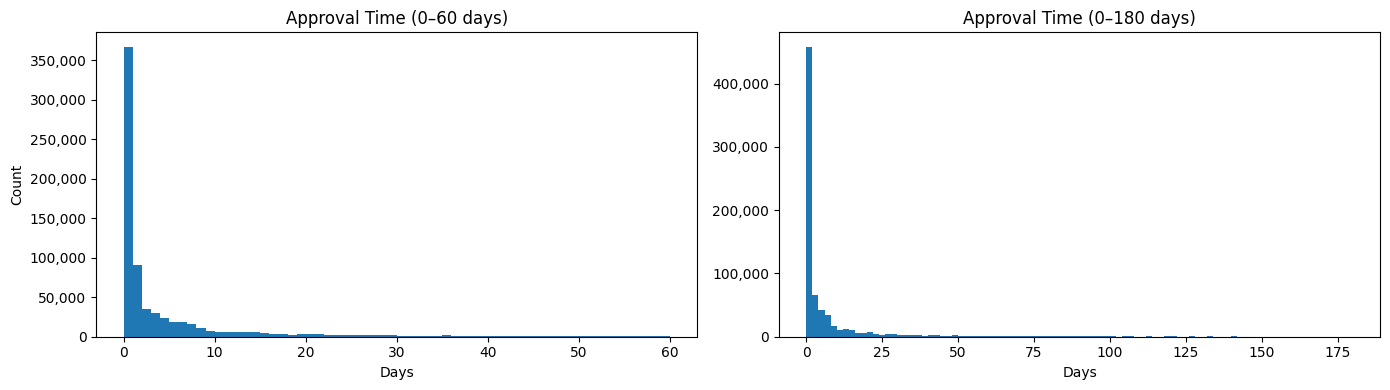

Median: 1 days
Mean:   17 days
p75:    6 days
p90:    28 days
p99:    336 days
% approved within 7 days:  79.2%
% approved within 30 days: 90.7%


In [94]:
approval = single_trade_permits['Approval_Time'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Zoomed to 0-60 days
axes[0].hist(approval[approval <= 60], bins=60, edgecolor='none')
axes[0].set_title('Approval Time (0–60 days)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Zoomed to 0-180 days
axes[1].hist(approval[approval <= 180], bins=90, edgecolor='none')
axes[1].set_title('Approval Time (0–180 days)')
axes[1].set_xlabel('Days')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print(f"Median: {approval.median():.0f} days")
print(f"Mean:   {approval.mean():.0f} days")
print(f"p75:    {approval.quantile(0.75):.0f} days")
print(f"p90:    {approval.quantile(0.90):.0f} days")
print(f"p99:    {approval.quantile(0.99):.0f} days")
print(f"% approved within 7 days:  {(approval <= 7).mean():.1%}")
print(f"% approved within 30 days: {(approval <= 30).mean():.1%}")

### Stat 1: Average and median days to receive a permit

In [95]:
approval = single_trade_permits['Approval_Time'].dropna()

print(f"Average approval time: {approval.mean():.0f} days")
print(f"Median approval time:  {approval.median():.0f} days")
print(f"n: {len(approval):,}")

Average approval time: 17 days
Median approval time:  1 days
n: 758,235


### Stat 1a: Distributions of approval times

In [96]:
approval = single_trade_permits['Approval_Time'].dropna()

q25 = approval.quantile(0.25)
q75 = approval.quantile(0.75)

print(f"n: {len(approval):,}")
print(f"Fastest 25% (<= {q25:.0f} days): median = {approval[approval <= q25].median():.1f} days")
print(f"Slowest 25% (>= {q75:.0f} days): median = {approval[approval >= q75].median():.1f} days")

n: 758,235
Fastest 25% (<= 0 days): median = 0.0 days
Slowest 25% (>= 6 days): median = 19.0 days


### Stat 2: Approval time by jurisdiction quartile

In [98]:
# Median approval time per jurisdiction, excluding 0-day medians
juris_approval = (
    single_trade_permits.groupby('JURISDICTION')['Approval_Time']
    .median()
    .dropna()
)

q25 = juris_approval.quantile(0.25)
q75 = juris_approval.quantile(0.75)

print(f"Jurisdictions analyzed: {len(juris_approval):,}")
print(f"Fastest 25% of jurisdictions (median <= {q25:.0f} days): median = {juris_approval[juris_approval <= q25].median():.0f} days")
print(f"Slowest 25% of jurisdictions (median >= {q75:.0f} days): median = {juris_approval[juris_approval >= q75].median():.0f} days")

Jurisdictions analyzed: 57
Fastest 25% of jurisdictions (median <= 0 days): median = 0 days
Slowest 25% of jurisdictions (median >= 4 days): median = 8 days


### Stat 3: Permit cost by jurisdiction quartile (2022–2024)

In [70]:
# Filter to 2022-2024 and valid fees
recent = single_trade_permits[single_trade_permits['Year'].between(2022, 2024)].copy()
recent['FEES'] = pd.to_numeric(recent['FEES'], errors='coerce')
recent = recent[recent['FEES'] > 0]

# Median fee per jurisdiction
juris_fees = recent.groupby('JURISDICTION')['FEES'].median().dropna()

q25 = juris_fees.quantile(0.25)
q75 = juris_fees.quantile(0.75)

print(f"Jurisdictions analyzed: {len(juris_fees):,}")
print(f"Overall median fee: ${juris_fees.median():,.0f}")
print(f"Cheapest 25% of jurisdictions (median <= ${q25:.0f}): median = ${juris_fees[juris_fees <= q25].median():,.0f}")
print(f"Most expensive 25% (median >= ${q75:.0f}): median = ${juris_fees[juris_fees >= q75].median():,.0f}")

Jurisdictions analyzed: 27
Overall median fee: $84
Cheapest 25% of jurisdictions (median <= $75): median = $75
Most expensive 25% (median >= $106): median = $180


### Stat 4: Correlation between approval time and project completion time (jurisdiction level)

In [71]:
from scipy import stats

# Filter to 2020-2024
permits_2020_2024 = single_trade_permits[single_trade_permits['Year'].between(2020, 2024)]

# Aggregate to jurisdiction level medians + counts
juris_reg = permits_2020_2024.groupby('JURISDICTION')[['Approval_Time', 'Project_Time']].agg(
    ['median', 'count']
)
juris_reg.columns = ['_'.join(c) for c in juris_reg.columns]
juris_reg = juris_reg.rename(columns={
    'Approval_Time_median': 'Approval_Time',
    'Project_Time_median': 'Project_Time',
    'Approval_Time_count': 'n_approval',
    'Project_Time_count': 'n_project',
})

MAX_MEDIAN_PROJECT_TIME = 300  # days — exclude jurisdictions with unusually long median project times

juris_reg = juris_reg.dropna(subset=['Approval_Time', 'Project_Time'])
juris_reg = juris_reg[
    (juris_reg['Approval_Time'] > 0) &
    (juris_reg['Project_Time'] > 0) &
    (juris_reg['Project_Time'] <= MAX_MEDIAN_PROJECT_TIME) &
    (juris_reg['n_approval'] >= 100) &
    (juris_reg['n_project'] >= 100)
]

slope, intercept, r, p, se = stats.linregress(juris_reg['Approval_Time'], juris_reg['Project_Time'])

print(f"Jurisdictions in regression: {len(juris_reg):,}")
print(f"Slope (project days per approval day): {slope:.2f}")
print(f"Intercept:                             {intercept:.1f}")
print(f"R²:                                    {r**2:.3f}")
print(f"p-value:                               {p:.2e}")
print()
display(juris_reg[['Approval_Time', 'Project_Time', 'n_approval', 'n_project']].sort_values('Approval_Time'))

Jurisdictions in regression: 25
Slope (project days per approval day): 7.87
Intercept:                             57.8
R²:                                    0.379
p-value:                               1.06e-03



,Approval_Time,Project_Time,n_approval,n_project
JURISDICTION,,,,
BURLINGTON,1.00,147.00,14097,14097
PERSON COUNTY,1.00,26.00,2084,2084
NEW HANOVER COUNTY,1.00,85.00,70185,70185
GASTON COUNTY,1.00,17.00,13998,13998
DURHAM COUNTY,1.00,46.00,4726,4726
LEE COUNTY,1.00,112.00,11124,11124
WAXHAW,1.00,181.00,4208,4208
DURHAM,1.00,62.00,44420,44420
HARNETT COUNTY,2.00,47.50,7594,7594


### Stat 5: Permit approval time quartiles (all permits)

n: 417,686
Fastest 25% (<= 2 days): median = 1.0 days
Slowest 25% (>= 17 days): median = 47.0 days


In [ ]:
durham_2024 = single_trade_permits[
    (single_trade_permits['JURISDICTION'].str.upper().isin(['DURHAM', 'DURHAM COUNTY'])) &
    (single_trade_permits['Year'] == 2024)
]

print(f"Total Durham records (2024): {len(durham_2024):,}")
print(durham_2024['JURISDICTION'].value_counts())

new_construction_in_subtype = durham_2024['SUBTYPE'].fillna('').str.contains('new construction', case=False)
print(f"\nRecords with 'new construction' in SUBTYPE: {new_construction_in_subtype.sum():,}")
durham_2024